In [2]:
# Core libraries
import pandas as pd
import numpy as np
import re
from datetime import datetime
import sys
print(sys.executable)
# The star of the show
from google_play_scraper import app, reviews, Sort

print("Libraries loaded successfully!")

c:\Users\cbe\Desktop\Web_Scraping\.venv\Scripts\python.exe
Libraries loaded successfully!


In [3]:
from google_play_scraper import app, reviews, Sort
import pandas as pd

# ==============================
# App IDs (fixed + clarified)
# ==============================
APPS = {
    "CBE Mobile Banking": "com.combanketh.mobilebanking",
    "Dashen Bank": "com.dashen.dashensuperapp",
    "BOA Mobile Banking": "com.boa.boaMobileBanking"
}

TARGET_REVIEWS = 500
all_reviews = []

# ==============================
# STEP 1: App Metadata + Reviews
# ==============================
for bank_name, app_id in APPS.items():

    print("\n" + "=" * 50)
    print(f"Processing: {bank_name}")
    print("=" * 50)

    # Get app metadata
    info = app(app_id, lang='en', country='et')

    print(f"App Title   : {info['title']}")
    print(f"Score       : {info['score']}")
    print(f"Ratings     : {info['ratings']:,}")
    print(f"Reviews     : {info['reviews']:,}")
    print(f"Installs    : {info['installs']}")

    # ==============================
    # STEP 2: Scrape Reviews (400+)
    # ==============================
    collected = []
    token = None

    while len(collected) < TARGET_REVIEWS:
        batch, token = reviews(
            app_id,
            lang='en',
            country='et',
            sort=Sort.NEWEST,
            count=500,
            continuation_token=token
        )

        if not batch:
            break

        collected.extend(batch)

        if token is None:
            break

    print(f"Collected Reviews: {len(collected)}")

    # ==============================
    # STEP 3: Format Data
    # ==============================
    for r in collected[:TARGET_REVIEWS]:

        # skip empty reviews
        if not r['content'] or len(r['content'].strip()) < 3:
            continue

        all_reviews.append({
            "bank": bank_name,
            "app_name": info['title'],
            "review_text": r['content'],
            "rating": r['score'],
            "review_date": r['at'],
            "source": "Google Play"
        })

# ==============================
# STEP 4: Create Dataset
# ==============================
df = pd.DataFrame(all_reviews)

print("\nFINAL DATASET SHAPE:", df.shape)
print(df.head())

# Save dataset
df.to_csv("data/bank_reviews.csv", index=False)
print("\nSaved to data/bank_reviews.csv")


Processing: CBE Mobile Banking
App Title   : Commercial Bank of Ethiopia
Score       : 4.2870197
Ratings     : 48,615
Reviews     : 9,341
Installs    : 10,000,000+
Collected Reviews: 500

Processing: Dashen Bank
App Title   : Dashen Bank
Score       : 4.2581167
Ratings     : 5,702
Reviews     : 1,029
Installs    : 1,000,000+
Collected Reviews: 500

Processing: BOA Mobile Banking
App Title   : BoA Mobile
Score       : 4.4006343
Ratings     : 9,301
Reviews     : 1,470
Installs    : 1,000,000+
Collected Reviews: 500

FINAL DATASET SHAPE: (1458, 6)
                 bank                     app_name  \
0  CBE Mobile Banking  Commercial Bank of Ethiopia   
1  CBE Mobile Banking  Commercial Bank of Ethiopia   
2  CBE Mobile Banking  Commercial Bank of Ethiopia   
3  CBE Mobile Banking  Commercial Bank of Ethiopia   
4  CBE Mobile Banking  Commercial Bank of Ethiopia   

                                         review_text  rating  \
0                                               pels       

In [4]:
import pandas as pd

df = pd.read_csv("data/bank_reviews.csv")

print(df.shape)
df.head()

(1458, 6)


,bank,app_name,review_text,rating,review_date,source
0,CBE Mobile Banking,Commercial Bank of Ethiopia,pels,5,2026-05-18 08:15:35,Google Play
1,CBE Mobile Banking,Commercial Bank of Ethiopia,What an excellent app with smooth performance !!,5,2026-05-18 07:36:31,Google Play
2,CBE Mobile Banking,Commercial Bank of Ethiopia,በጣም ጥሩ ነው እነማሰግነለን,5,2026-05-18 05:55:46,Google Play
3,CBE Mobile Banking,Commercial Bank of Ethiopia,svabst keessatti argamu yoo ta'u yeroo ammaa k...,5,2026-05-18 01:12:03,Google Play
4,CBE Mobile Banking,Commercial Bank of Ethiopia,nays,5,2026-05-17 18:46:14,Google Play


In [5]:
import pandas as pd

# Load your existing data
df = pd.read_csv("data/bank_reviews.csv")

# -------------------------------
# 1. Rename columns
# -------------------------------
df = df.rename(columns={
    "review_text": "review",
    "review_date": "date"
})

# -------------------------------
# 2. Normalize date format
# -------------------------------
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Convert to YYYY-MM-DD
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

# -------------------------------
# 3. Keep only required columns
# -------------------------------
df = df[["app_name", "bank","review", "rating", "date", "source",]]

# -------------------------------
# 4. Drop missing values (important)
# -------------------------------
df = df.dropna(subset=["review", "rating", "date"])

# -------------------------------
# 5. Optional: remove duplicates
# -------------------------------
df = df.drop_duplicates()

# -------------------------------
# 6. Save cleaned dataset
# -------------------------------
df.to_csv("data/cleaned_bank_reviews.csv", index=False)

print("Final shape:", df.shape)
print(df.head())

Final shape: (1438, 6)
                      app_name                bank  \
0  Commercial Bank of Ethiopia  CBE Mobile Banking   
1  Commercial Bank of Ethiopia  CBE Mobile Banking   
2  Commercial Bank of Ethiopia  CBE Mobile Banking   
3  Commercial Bank of Ethiopia  CBE Mobile Banking   
4  Commercial Bank of Ethiopia  CBE Mobile Banking   

                                              review  rating        date  \
0                                               pels       5  2026-05-18   
1   What an excellent app with smooth performance !!       5  2026-05-18   
2                                 በጣም ጥሩ ነው እነማሰግነለን       5  2026-05-18   
3  svabst keessatti argamu yoo ta'u yeroo ammaa k...       5  2026-05-18   
4                                               nays       5  2026-05-17   

        source  
0  Google Play  
1  Google Play  
2  Google Play  
3  Google Play  
4  Google Play  


In [6]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis")
def classify_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]

        label = result['label']
        score = result['score']

        # Convert to 3-class sentiment
        if score < 0.6:
            final_label = "NEUTRAL"
        elif label == "POSITIVE":
            final_label = "POSITIVE"
        else:
            final_label = "NEGATIVE"

        return final_label, score

    except:
        return "ERROR", 0
    
import pandas as pd

df = pd.read_csv("data/cleaned_bank_reviews.csv")

df[["sentiment", "confidence"]] = df["review"].apply(
    lambda x: pd.Series(classify_sentiment(x))
)

print(df.head())
df.to_csv("data/sentiment_reviews.csv", index=False)
print(df["sentiment"].value_counts())

c:\Users\cbe\Desktop\Web_Scraping\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13873.85it/s]


                      app_name                bank  \
0  Commercial Bank of Ethiopia  CBE Mobile Banking   
1  Commercial Bank of Ethiopia  CBE Mobile Banking   
2  Commercial Bank of Ethiopia  CBE Mobile Banking   
3  Commercial Bank of Ethiopia  CBE Mobile Banking   
4  Commercial Bank of Ethiopia  CBE Mobile Banking   

                                              review  rating        date  \
0                                               pels       5  2026-05-18   
1   What an excellent app with smooth performance !!       5  2026-05-18   
2                                 በጣም ጥሩ ነው እነማሰግነለን       5  2026-05-18   
3  svabst keessatti argamu yoo ta'u yeroo ammaa k...       5  2026-05-18   
4                                               nays       5  2026-05-17   

        source sentiment  confidence  
0  Google Play  POSITIVE    0.995754  
1  Google Play  POSITIVE    0.999850  
2  Google Play  NEGATIVE    0.861633  
3  Google Play  NEGATIVE    0.997694  
4  Google Play  NEGATIV

In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']

    if score >= 0.05:
        label = "POSITIVE"
    elif score <= -0.05:
        label = "NEGATIVE"
    else:
        label = "NEUTRAL"

    return label, score
df[["sentiment", "sentiment_score"]] = df["review"].apply(
    lambda x: pd.Series(get_sentiment(x))
)
df.to_csv("data/sentiment_reviews_vader.csv", index=False)

In [8]:
bank_sentiment = df.groupby("bank")["sentiment_score"].mean().reset_index()

print(bank_sentiment)

                 bank  sentiment_score
0  BOA Mobile Banking         0.181520
1  CBE Mobile Banking         0.276708
2         Dashen Bank         0.295870


In [16]:
rating_sentiment = df.groupby("rating")["sentiment_score"].mean().reset_index()

print(rating_sentiment)

   rating  sentiment_score
0       1        -0.139359
1       2         0.079777
2       3         0.095818
3       4         0.295861
4       5         0.409570


In [13]:
bank_rating_sentiment = df.groupby(["bank", "rating"])["sentiment_score"].mean().reset_index()

print(bank_rating_sentiment)

                  bank  rating  sentiment_score
0   BOA Mobile Banking       1        -0.162542
1   BOA Mobile Banking       2         0.055212
2   BOA Mobile Banking       3         0.139511
3   BOA Mobile Banking       4         0.349397
4   BOA Mobile Banking       5         0.358604
5   CBE Mobile Banking       1        -0.044437
6   CBE Mobile Banking       2         0.177538
7   CBE Mobile Banking       3        -0.052745
8   CBE Mobile Banking       4         0.193757
9   CBE Mobile Banking       5         0.408436
10         Dashen Bank       1        -0.174819
11         Dashen Bank       2         0.031006
12         Dashen Bank       3         0.248267
13         Dashen Bank       4         0.375218
14         Dashen Bank       5         0.455233


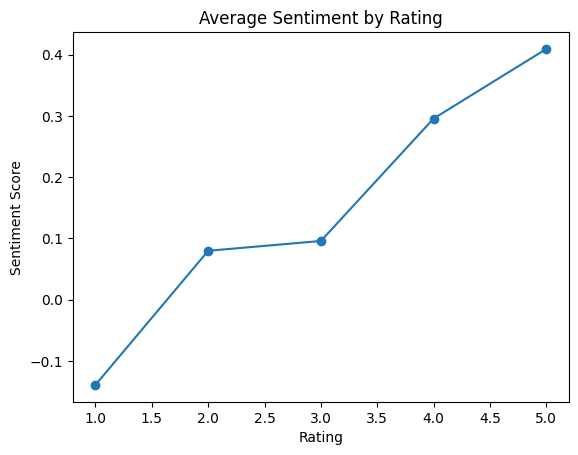

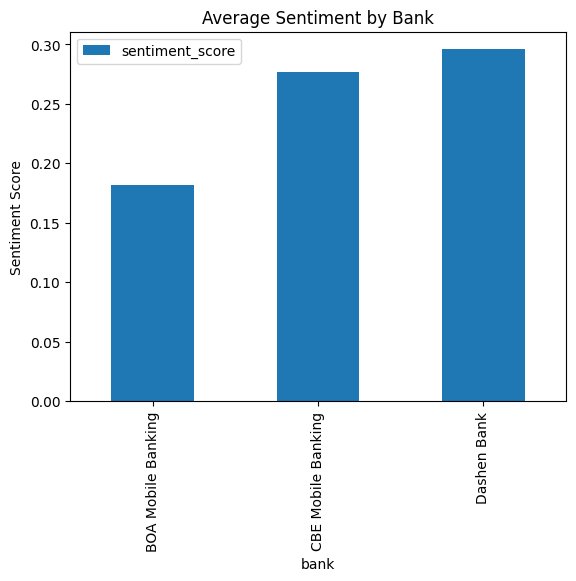

In [17]:
import matplotlib.pyplot as plt

plt.plot(rating_sentiment["rating"], rating_sentiment["sentiment_score"], marker='o')
plt.title("Average Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.show()

bank_sentiment.set_index("bank").plot(kind="bar")
plt.title("Average Sentiment by Bank")
plt.ylabel("Sentiment Score")
plt.show()

Aggregated sentiment scores revealed a strong relationship between star ratings and sentiment polarity. Lower-rated reviews (1–2 stars) were associated with low sentiment scores, while higher-rated reviews (4–5 stars) showed high sentiment. This consistency validates the reliability of the sentiment analysis approach.

In [34]:
themes = {
    "Account Access Issues": ["login", "log in", "password", "otp", "verify", "authentication"],
    "Transaction Performance": ["transaction", "transfer", "delay", "failed", "processing", "slow","excellent","worst","poor","awesome","functional","problem","good"],
    "UI & Design": ["interface", "design", "ui", "layout", "user friendly", "navigation"],
    "Customer Support": ["support", "service", "help", "customer care", "response"],
    "Feature Requests": ["feature", "add", "update", "option", "improve"]
}
def assign_theme(text):
    text = str(text).lower()

    for theme, keywords in themes.items():
        for word in keywords:
            if word in text:
                return theme

    return "Other"
df["theme"] = df["review"].apply(assign_theme)

print(df["theme"].value_counts())
print("/////////////////////////////////////////////////")
import pandas as pd

print(pd.crosstab(df["theme"], df["sentiment"]))

print("/////////////////////////////////////////////////")

print(pd.crosstab(df["bank"], df["theme"]))

theme
Other                      825
Transaction Performance    475
Feature Requests            57
UI & Design                 28
Account Access Issues       27
Customer Support            26
Name: count, dtype: int64
/////////////////////////////////////////////////
sentiment                NEGATIVE  NEUTRAL  POSITIVE
theme                                               
Account Access Issues           8        7        12
Customer Support                3        4        19
Feature Requests               16       16        25
Other                          78      301       446
Transaction Performance        96       33       346
UI & Design                     7        0        21
/////////////////////////////////////////////////
theme               Account Access Issues  Customer Support  Feature Requests  \
bank                                                                            
BOA Mobile Banking                     18                 5                13   
CBE Mobile Bank

Thematic analysis was conducted by categorizing reviews into predefined business-relevant themes based on keyword matching. These themes included account access issues, transaction performance, user interface design, customer support, and feature requests. This approach enabled the identification of recurring issues and key drivers of customer satisfaction across different banking applications.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    ngram_range=(1, 2)  # unigram + bigram
)

X = vectorizer.fit_transform(df["review"])
feature_names = vectorizer.get_feature_names_out()

tfidf_scores = np.mean(X.toarray(), axis=0)

top_indices = tfidf_scores.argsort()[-20:][::-1]

top_keywords = [feature_names[i] for i in top_indices]

print(top_keywords)

print("////////////////////////////////////////////////////")
for bank in df["bank"].unique():
    subset = df[df["bank"] == bank]

    X_bank = vectorizer.fit_transform(subset["review"])
    scores = np.mean(X_bank.toarray(), axis=0)

    top_idx = scores.argsort()[-10:][::-1]
    keywords = [vectorizer.get_feature_names_out()[i] for i in top_idx]

    print(f"\nTop keywords for {bank}:")
    print(keywords)
    print("////////////////////////////////////////////////////////")
for sentiment in ["POSITIVE", "NEGATIVE"]:
    subset = df[df["sentiment"] == sentiment]

    X_s = vectorizer.fit_transform(subset["review"])
    scores = np.mean(X_s.toarray(), axis=0)

    top_idx = scores.argsort()[-10:][::-1]
    keywords = [vectorizer.get_feature_names_out()[i] for i in top_idx]

    print(f"\nTop {sentiment} keywords:")
    print(keywords)


['good', 'app', 'nice', 'best', 'bank', 'working', 'use', 'like', 'excellent', 'fast', 'good app', 'nice app', 'best app', 'easy', 'great', 'banking', 'work', 'wow', 'application', 'amazing']
////////////////////////////////////////////////////

Top keywords for CBE Mobile Banking:
['good', 'app', 'nice', 'best', 'cbe', 'like', 'nice app', 'working', 'excellent', 'use']
////////////////////////////////////////////////////////

Top keywords for Dashen Bank:
['good', 'app', 'nice', 'best', 'bank', 'dashen', 'nice app', 'great', 'super', 'easy']
////////////////////////////////////////////////////////

Top keywords for BOA Mobile Banking:
['good', 'app', 'best', 'nice', 'boa', 'working', 'bank', 'work', 'good app', 'mobile']
////////////////////////////////////////////////////////

Top POSITIVE keywords:
['good', 'nice', 'app', 'best', 'excellent', 'good app', 'nice app', 'best app', 'like', 'bank']

Top NEGATIVE keywords:
['app', 'worst', 'bad', 'worst app', 'problem', 'bank', 'working',

TF-IDF vectorization was applied to extract significant keywords and n-grams from user reviews. Both unigrams and bigrams were analyzed to capture meaningful phrases such as “login error” and “slow transfer”. The extracted terms were further analyzed by bank and sentiment category to identify recurring issues and key drivers of customer satisfaction.

In [36]:
import sys
sys.path.append("./src")

from preprocessing import preprocess_text

df["processed_review"] = df["review"].apply(preprocess_text)

df[["review", "processed_review"]].head(15)

,review,processed_review
0,pels,pel
1,What an excellent app with smooth performance !!,excellent app smooth performance
2,በጣም ጥሩ ነው እነማሰግነለን,በጣም ጥሩ ነው እነማሰግነለን
3,svabst keessatti argamu yoo ta'u yeroo ammaa k...,svabst keessatti argamu yoo yeroo ammaa kanas ...
4,nays,nay
5,very very good 👍 thanks commercial bank of eth...,good thank commercial bank ethiopia
6,so nice,nice
7,fantastic,fantastic
8,very nice,nice
9,f*k,


In [37]:
df["review_id"] = range(1, len(df) + 1)
final_df = df[[
    "review_id",
    "review",
    "sentiment",
    "sentiment_score",
    "theme"
]].copy()
final_df = final_df.rename(columns={
    "review": "review_text",
    "sentiment": "sentiment_label",
    "theme": "identified_theme"
})
final_df.to_csv("data/final_sentiment_themes.csv", index=False)